In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/My Drive/Crime Analysis')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install japanize-matplotlib --quiet
import japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 37.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=abe7535ede2975d69f239f33666cb104220e2f9d7136ea9742ac5280b63cc332
  Stored in directory: /root/.cache/pip/wheels/61/7a/6b/df1f79be9c59862525070e157e62b08eab8ece27c1b68fbb94
Successfully built japanize-matplotlib


In [ ]:
df = pd.DataFrame()

In [ ]:
for filename in os.listdir('data/case'):
    if filename.endswith('.csv'):
        df = pd.concat([df, pd.read_csv('data/case/' + filename)])

In [ ]:
df.sort_values('発生年月日（始期）', ascending=False).head(50)

,罪名,手口,管轄警察署（発生地）,管轄交番・駐在所（発生地）,市区町村コード（発生地）,都道府県（発生地）,市区町村（発生地）,町丁目（発生地）,発生年月日（始期）,発生時（始期）,...,name,latitude,longitude,police_office_name,police_office_latitude,police_office_longitude,盗難防止装置の有無,現金以外の主な被害品,被害者の性別,現金被害の有無
36,窃盗,オートバイ盗,品川,三ツ木交番,131091.0,東京都,品川区,西品川３丁目,不明,不明,...,品川区西品川３丁目,35.615971,139.726676,品川警察署 三ツ木交番,NaN,NaN,なし,自動二輪（50cc超）,NaN,NaN
559,窃盗,オートバイ盗,多摩中央,貝取交番,132241.0,東京都,多摩市,貝取３丁目,不明,不明,...,多摩市貝取３丁目,35.616718,139.441297,多摩中央警察署 貝取交番,NaN,NaN,なし,自動二輪（50cc超）,NaN,NaN
7576,窃盗,自転車盗,荻窪,桃井四丁目交番,131156.0,東京都,杉並区,上荻４丁目,不明,不明,...,杉並区上荻４丁目,35.710036,139.605010,荻窪警察署 桃井四丁目交番,35.712299,139.602057,NaN,NaN,NaN,NaN
4347,窃盗,自転車盗,目黒,大橋交番,131105.0,東京都,目黒区,大橋２丁目,2022/9/9,11,...,目黒区大橋２丁目,35.653404,139.686551,目黒警察署 大橋交番,35.652434,139.687853,NaN,NaN,NaN,NaN
20746,窃盗,自転車盗,三鷹,三鷹駅前交番,132047.0,東京都,三鷹市,上連雀４丁目,2022/9/9,8,...,三鷹市上連雀４丁目,NaN,NaN,三鷹警察署 三鷹駅前交番,NaN,NaN,NaN,NaN,NaN,NaN
20294,窃盗,自転車盗,東村山,清瀬駅前交番,132217.0,東京都,清瀬市,元町１丁目,2022/9/9,8,...,清瀬市元町１丁目,35.773680,139.518728,東村山警察署 清瀬駅前交番,35.772355,139.519788,NaN,NaN,NaN,NaN
20368,窃盗,自転車盗,東村山,秋津駅前交番,132217.0,東京都,清瀬市,野塩５丁目,2022/9/9,14,...,清瀬市野塩５丁目,35.776137,139.499524,東村山警察署 秋津駅前交番,35.778235,139.496914,NaN,NaN,NaN,NaN
20480,窃盗,自転車盗,武蔵野,八幡宮西交番,132039.0,東京都,武蔵野市,吉祥寺本町１丁目,2022/9/9,16,...,武蔵野市吉祥寺本町１丁目,35.705245,139.581005,武蔵野警察署 八幡宮西交番,NaN,NaN,NaN,NaN,NaN,NaN
3466,窃盗,自転車盗,北沢,赤堤交番,131121.0,東京都,世田谷区,赤堤１丁目,2022/9/9,0,...,世田谷区赤堤１丁目,35.655192,139.641583,北沢警察署 赤堤交番,35.657154,139.642381,NaN,NaN,NaN,NaN
16443,窃盗,自転車盗,南大沢,堀之内駅前交番,132012.0,東京都,八王子市,堀之内３丁目,2022/9/9,17,...,八王子市堀之内３丁目,NaN,NaN,南大沢警察署 堀之内駅前交番,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
pd.set_option('display.max_rows', 50)
df.sort_values('発生年月日（始期）', ascending=False).groupby('発生年月日（始期）').count()['name'].sort_values(ascending=False).head(50)

,name
発生年月日（始期）,
2022/9/30,133
2022/10/21,120
2022/9/16,119
2022/9/10,114
2022/9/15,110
2022/7/9,109
2022/8/31,109
2022/9/26,106
2022/8/1,106


In [ ]:
from geopy.distance import geodesic
from itertools import combinations

In [ ]:
def mean_distance(group):
    valid_points = group.dropna(subset=['latitude', 'longitude'])
    if len(valid_points) < 2:
        return np.nan

    pairs = list(combinations(valid_points.index, 2))
    distances = []

    for (i, j) in pairs:
        point1 = (valid_points.loc[i, 'latitude'].iloc[0] if isinstance(valid_points.loc[i, 'latitude'], pd.Series) else valid_points.loc[i, 'latitude'],
                  valid_points.loc[i, 'longitude'].iloc[0] if isinstance(valid_points.loc[i, 'longitude'], pd.Series) else valid_points.loc[i, 'longitude'])
        point2 = (valid_points.loc[j, 'latitude'].iloc[0] if isinstance(valid_points.loc[j, 'latitude'], pd.Series) else valid_points.loc[j, 'latitude'],
                  valid_points.loc[j, 'longitude'].iloc[0] if isinstance(valid_points.loc[j, 'longitude'], pd.Series) else valid_points.loc[j, 'longitude'])
        distance = geodesic(point1, point2).meters
        distances.append(distance)

    return np.mean(distances) if distances else np.nan

In [ ]:
mean_dists = df.sort_values('発生年月日（始期）', ascending=False).groupby('発生年月日（始期）').apply(mean_distance)
mean_dists.sort_values(ascending=True).head(10)

In [ ]:
df[df['発生年月日（始期）'].isin(mean_dists.sort_values(ascending=True).head(5).index)].iloc[:, :-14].reset_index(drop=True)

,罪名,手口,管轄警察署（発生地）,管轄交番・駐在所（発生地）,市区町村コード（発生地）,都道府県（発生地）,市区町村（発生地）,町丁目（発生地）,発生年月日（始期）,発生時（始期）,発生場所
0,窃盗,自転車盗,巣鴨,サンシャイン前交番,131164.0,東京都,豊島区,東池袋２丁目,2019/11/4,22,その他の住宅（３階建て以下共同住宅等）
1,窃盗,自転車盗,巣鴨,サンシャイン前交番,131164.0,東京都,豊島区,東池袋２丁目,2019/11/4,22,その他の住宅（３階建て以下共同住宅等）
2,窃盗,ひったくり,新宿,大久保交番,131041.0,東京都,新宿区,大久保２丁目,2022-06-04,4,道路上
3,窃盗,ひったくり,新宿,歌舞伎町交番,131041.0,東京都,新宿区,歌舞伎町２丁目,2022-06-04,4,道路上
4,窃盗,車上ねらい,福生,長岡駐在所,133035.0,東京都,瑞穂町,長岡４丁目,2021/7/13,13,その他
5,窃盗,車上ねらい,福生,長岡駐在所,133035.0,東京都,瑞穂町,長岡４丁目,2021/7/13,13,その他
6,窃盗,車上ねらい,府中,是政交番,132063.0,東京都,府中市,小柳町４丁目,2018/12/1,不明,その他
7,窃盗,車上ねらい,府中,是政交番,132063.0,東京都,府中市,小柳町４丁目,2018/12/1,不明,その他の住宅（３階建て以下共同住宅等）
8,窃盗,車上ねらい,府中,車返団地駐在所,132063.0,東京都,府中市,押立町４丁目,2018/12/1,不明,一戸建住宅
9,窃盗,自動販売機ねらい,麹町,九段下交番,131016.0,東京都,千代田区,九段南２丁目,2022-01-12,19,その他


In [ ]:
mean_dists.sort_values(ascending=True).head(50)

,0
発生年月日（始期）,
2021/7/13,0.000000
2019/11/4,0.000000
2022-01-12,344.323810
2022-06-04,698.246720
2018/12/1,804.791651
2022-03-15,984.595010
2022-02-14,1139.117105
2022-01-29,1241.817907
2022-08-09,2140.944240


<Axes: xlabel='発生年月日（始期）'>

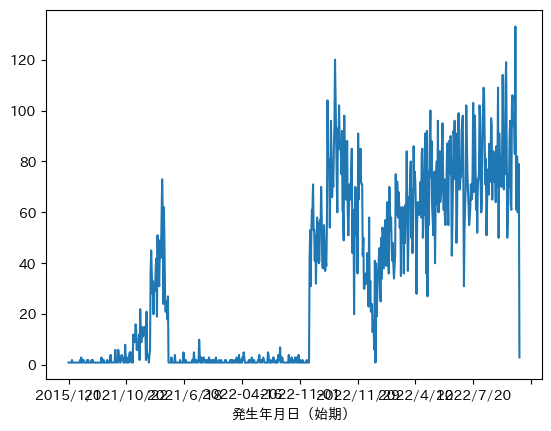

In [ ]:
df.sort_values('発生年月日（始期）', ascending=False).groupby('発生年月日（始期）')['市区町村（発生地）'].count().plot()

In [ ]:
pd.set_option('display.max_rows', 50)
df.groupby(['発生年月日（始期）', '市区町村（発生地）']).size().reset_index(name='count').sort_values(by=['count', '発生年月日（始期）'], ascending=[False, False]).head(50)

,発生年月日（始期）,市区町村（発生地）,count
6396,2022/4/17,台東区,14
11638,2022/9/29,大田区,12
11556,2022/9/26,足立区,12
7720,2022/5/29,大田区,12
3033,2022/10/4,江戸川区,12
2604,2022/10/21,世田谷区,12
10971,2022/9/10,新宿区,11
9918,2022/8/1,世田谷区,11
2180,2022/10/1,世田谷区,11
11694,2022/9/30,世田谷区,10
